<a href="https://colab.research.google.com/github/thisishasan/cbir_system/blob/main/10_train_auto_encoder_subclass_1_400.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
%cd '/content/drive/My Drive/01_information_retrieval'
!ls

/content/drive/My Drive/01_information_retrieval
binary_scenario		      training_1_200_subclass
checkpoint		      training_1_200_subclass.h5
Notes.gdoc		      training_1_200_subclass.json
original		      training_1_40
reconstruction		      training_1_400
subclass_scenario	      training_1_400.h5
tflite_model		      training_1_400.json
training_1_100		      training_1_40.h5
training_1_100.h5	      training_1_40.json
training_1_100.json	      training_1_40_subclass
training_1_100_subclass       training_1_40_subclass.h5
training_1_100_subclass.h5    training_1_40_subclass.json
training_1_100_subclass.json  training_1_indexed_100.json
training_1_200		      training_1_indexed_200.json
training_1_200.h5	      training_1_indexed_400.json
training_1_200.json	      training_1_indexed_40.json


In [19]:
import matplotlib
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import json

In [20]:
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import Conv2DTranspose
from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras.layers import Activation
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Reshape
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model
from tensorflow.keras import backend as K
import numpy as np

In [21]:
class ConvAutoEncoder:
    @staticmethod
    def build(width, height, depth, filters=(128,), latent_dim=48):
        input_shape = (height, width, depth)
        channel_dim = -1
        inputs = Input(shape=input_shape)
        x = inputs
        # Encoder layer
        for f in filters:
            x = Conv2D(f, (3, 3), strides=2, padding='same')(x)
            x = LeakyReLU(negative_slope=0.2)(x)
            x = BatchNormalization(axis=channel_dim, name='enc_filter_'+str(f))(x)

        volume_size = K.int_shape(x)
        x = Flatten()(x)
        # Latent layer
        latent = Dense(latent_dim, name="encoded")(x)

        # Decoder layer
        x = Dense(int(np.prod(volume_size[1:])))(latent)
        x = Reshape((volume_size[1], volume_size[2], volume_size[3]))(x)

        # Reverse on decoder
        for f in filters[::-1]:
            x = Conv2DTranspose(f, (3, 3), strides=2, padding='same')(x)
            x = LeakyReLU(negative_slope=0.2)(x)
            x = BatchNormalization(axis=channel_dim, name='dec_filter_'+str(f))(x)

        x = Conv2DTranspose(depth, (3, 3), padding="same")(x)
        outputs = Activation("sigmoid", name="decoded")(x)

        auto_encoder = Model(inputs, outputs, name="auto_encoder")
        return auto_encoder

In [22]:
def visualize_predictions(_decoded, gt, samples=10):
    outputs = None
    for i in range(0, samples):
        original = (gt[i] * 255).astype("uint8")
        recon = (_decoded[i] * 255).astype("uint8")
        output = np.hstack([original, recon])
        outputs = output if outputs is None else np.vstack([outputs, output])
    return outputs

In [23]:
EPOCHS = 50
INIT_LR = 1e-3
BS = 32
IMAGE_SIZE = (256, 256)
checkpoint_path = "training_1_400_subclass/cp.ckpt.weights.h5"
checkpoint_dir = os.path.dirname(checkpoint_path)

In [24]:
print("[INFO] indexing file images BreaKHis dataset...")
base_dataset = "subclass_scenario"
magnification = "400X"
class_dir = ['tubular_adenoma', 'phyllodes_tumor', 'papillary_carcinoma',
             'mucinous_carcinoma', 'lobular_carcinoma', 'fibroadenoma',
             'ductal_carcinoma', 'adenosis'
             ]
type_dataset = ['val', 'train']
dataset_train = []
dataset_val = []
for type_set in type_dataset:
    for class_item in class_dir:
        cur_dir = os.path.join(base_dataset, type_set, magnification ,class_item)
        for file in os.listdir(cur_dir):
            if type_set == 'train':
                dataset_train.append(os.path.join(cur_dir, file))
            else:
                dataset_val.append(os.path.join(cur_dir, file))

[INFO] indexing file images BreaKHis dataset...


In [25]:
print("[INFO] load images BreaKHis dataset...")
#  load images
train_images = []
val_images = []
for type_set in type_dataset:
    cur_dataset = dataset_train if type_set == 'train' else dataset_val
    for image_path in cur_dataset:
        if ".png" in image_path:
            image = cv2.imread(image_path)
            image = cv2.resize(image, IMAGE_SIZE)
            if type_set == 'train':
                train_images.append(image)
            else:
                val_images.append(image)

[INFO] load images BreaKHis dataset...


In [26]:
# normalization
print("[INFO] normalization...")
train_x = np.array(train_images).astype("float32") / 255.0
val_x = np.array(val_images).astype("float32") / 255.0

[INFO] normalization...


In [27]:
print("[INFO] building auto encoder...")
auto_encoder = ConvAutoEncoder.build(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)
opt = Adam(learning_rate=INIT_LR)
checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_path,
    save_weights_only=True,
    monitor="val_loss",
    verbose = 1,
    mode='min',
    save_best_only=True)
auto_encoder.compile(loss="mse", optimizer=opt)
auto_encoder.summary()

[INFO] building auto encoder...


Model: "auto_encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 128)  │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 128, 128, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_filter_128                  │ (None, 128, 128, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2097152)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (Dense)                 │ (None, 48)             │   100,663,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2097152)        │   102,760,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 128, 128, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 256, 256, 128)  │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 256, 256, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_filter_128                  │ (None, 256, 256, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 256, 256, 3)    │         3,459 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoded (Activation)            │ (None, 256, 256, 3)    │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,579,443 (776.59 MB)

 Trainable params: 203,578,931 (776.59 MB)

 Non-trainable params: 512 (2.00 KB)

In [28]:
# train the convolutional auto encoder
print("[INFO] training auto encoder...")
H = auto_encoder.fit(
    train_x, train_x,
    shuffle=True,
    validation_data=(val_x, val_x),
    epochs=EPOCHS,
    callbacks = [checkpoint_callback],
    batch_size=16)

[INFO] training auto encoder...
Epoch 1/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step - loss: 0.0618
Epoch 1: val_loss improved from None to 0.02353, saving model to training_1_400_subclass/cp.ckpt.weights.h5

Epoch 1: finished saving model to training_1_400_subclass/cp.ckpt.weights.h5
93/93 ━━━━━━━━━━━━━━━━━━━━ 81s 814ms/step - loss: 0.0399 - val_loss: 0.0235
Epoch 2/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - loss: 0.0192
Epoch 2: val_loss improved from 0.02353 to 0.02335, saving model to training_1_400_subclass/cp.ckpt.weights.h5

Epoch 2: finished saving model to training_1_400_subclass/cp.ckpt.weights.h5
93/93 ━━━━━━━━━━━━━━━━━━━━ 68s 735ms/step - loss: 0.0192 - val_loss: 0.0234
Epoch 3/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - loss: 0.0190
Epoch 3: val_loss improved from 0.02335 to 0.02095, saving model to training_1_400_subclass/cp.ckpt.weights.h5

Epoch 3: finished saving model to training_1_400_subclass/cp.ckpt.weights.h5
93/93 ━━━━━━━━━━━━━━━━━━━━ 71s 773ms/step - loss: 0

[INFO] making predictions...
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 189ms/step


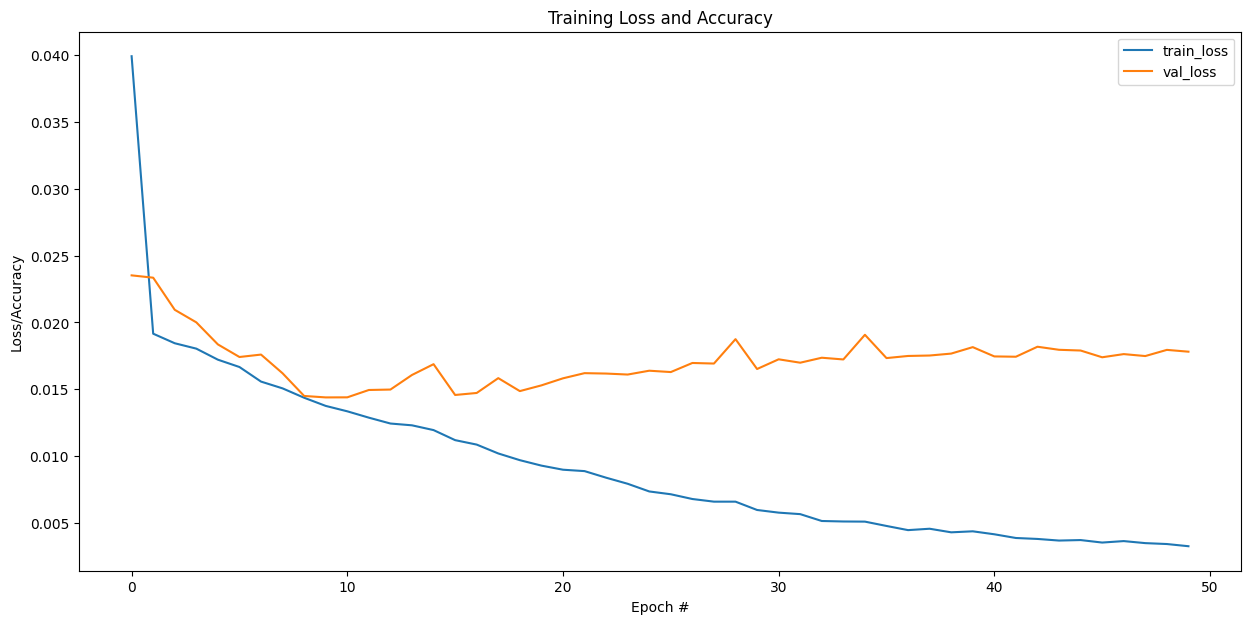

In [29]:
print("[INFO] making predictions...")
decoded = auto_encoder.predict(val_x)
vis = visualize_predictions(decoded, val_x)
image_example_path = "reconstruction"
cv2.imwrite(os.path.join(image_example_path,"recon_vis_400_subclass.png"), vis)
N = np.arange(0, EPOCHS)
plt.figure(figsize=(15,7))
plt.plot(N, H.history["loss"], label="train_loss")
plt.plot(N, H.history["val_loss"], label="val_loss")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()
plt.show()

In [30]:
with open('training_1_400_subclass.json', 'w') as f:
    json.dump(H.history, f)

In [31]:
auto_encoder.save('training_1_400_subclass.h5')